In [ ]:
import yaml
import sys 
sys.path.append('../')
from corpus.jsinV3DataLoader_precombined import jsinV3_precombined
import src.custom_modules as cm 

from src.coch_word_rec_lightning import CochWordRecModule

%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
path = '../config/coch_word_rec/word_rec_1e-4lr.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [ ]:
dataset = jsinV3_precombined(**config['data']['corpus'], train=True)

In [ ]:
audio_rep = cm.AudioInputRepresentation(**config['data']['audio']).cuda()

In [ ]:
config['n_jobs'] = 1
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = True
config['data']['audio']['rep_kwargs']['use_pad'] = True

config['data']['loader']['batch_size'] = 1


In [ ]:
model = CochWordRecModule(config)

In [ ]:
data = model.test_dataloader()

In [ ]:
on_gpu = config['data']['audio']['rep_kwargs']['rep_on_gpu']
for sample in iter(data):
    features = sample.features
    if on_gpu:
        features = features.to('cuda')
        features = audio_rep(features)
    print(features)
    break

In [ ]:
gpu_features = features.cpu().squeeze()

In [ ]:
plt.imshow(gpu_features, aspect='auto')
plt.title('on GPU')

In [97]:
cpu_features = features.squeeze()

Text(0.5, 1.0, 'on CPU')

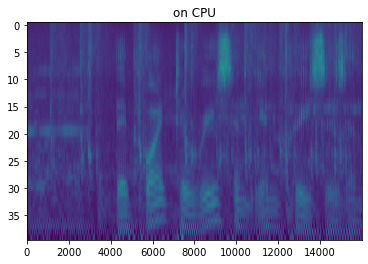

In [98]:
plt.imshow(cpu_features, aspect='auto')
plt.title('on CPU')

In [30]:
sample.features.shape

torch.Size([1, 1, 40, 16000])

In [47]:
import torch

In [50]:
torch.isclose(gpu_features, cpu_features).all()

tensor(False)

Text(0.5, 1.0, 'Difference: abs(GPU - CPU)')

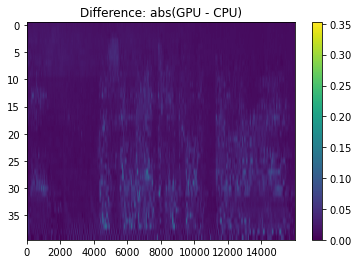

In [53]:
plt.imshow(abs(gpu_features - cpu_features), aspect='auto')
plt.colorbar()
plt.title('Difference: abs(GPU - CPU)')